<a href="https://colab.research.google.com/github/jmarrietar/LLMs-from-scratch-study/blob/main/Chapter_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preparar el dataset es clave para instruction `fine-tunning`

## Downloading the Dataset

Este es un dataset de 1100 instruction-response pairs

In [ ]:
import json
import os
import urllib

In [ ]:
def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()
    with open(file_path, "r") as file:
        data = json.load(file)
    return data
file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)
data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [ ]:
# Example
print("Example entry:\n", data[50])
print("Example entry:\n", data[49])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}
Example entry:
 {'instruction': "Name an antonym for 'happiness.'", 'input': '', 'output': "An antonym for 'happiness' is 'sadness.'"}


## Alpaca Style input format

In [ ]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
)
    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    return instruction_text + input_text


In [ ]:
model_input = format_input(data[50])

In [ ]:
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(desired_response)



### Response:
The correct spelling is 'Occasion.'


In [ ]:
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [ ]:
model_input = format_input(data[999])

In [ ]:
print(model_input)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?


In [ ]:
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [ ]:
len(data)

1100

## Partitioning the dataset

In [ ]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

In [ ]:
train_portion

935

In [ ]:
train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [ ]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


##7.3 Organizing data into training batches

In [ ]:
import torch
from torch.utils.data import Dataset

In [ ]:
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )
    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))


[50256]


custom collate function

In [ ]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )

        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

Esta funcion de `custom_collate_draft_1` se piensa utilizar dentro de un DataLoader o de forma individual.



In [ ]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

In [ ]:
batch

([0, 1, 2, 3, 4], [5, 6], [7, 8, 9])

In [ ]:
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


Utilizando este collate function podemos crear batches a partir de listas de inputs.

Similar al pre-training los **target tokens ** , match el input pero `shifted` una posicion a la derecha.

In [ ]:

def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )

        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:]) #Shifted by 1

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [ ]:
inputs, targets = custom_collate_draft_2(batch)

In [ ]:
inputs

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])

In [ ]:
targets

tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])

## 7.4 Creating data loaders for an instruction dataset

In [ ]:
def custom_collate_fn(
            batch,
            pad_token_id=50256,
            ignore_index=-100,
            allowed_max_length=None,
            device="cpu"
        ):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()

        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [ ]:
import torch

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.backends.mps.is_available():
#     device = torch.device("mps")"
print("Device:", device)

Device: cuda


In [ ]:
# No entiendo muy bien esta parte
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)


⚠️ **NOTA**: Tengo dudas de como esta funcionando el `InstructionDataset` y el `DataLoader`.

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
num_workers = 8
batch_size = 8

In [ ]:
torch.manual_seed(123)

In [ ]:
train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=custom_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=custom_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

In [ ]:
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=custom_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

In [ ]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)
    break

Train loader:


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([8, 61]) torch.Size([8, 61])


Thanks to our custom collate function, the data loader is able to create batches of different lengths.

In [ ]:
print(inputs[0])
len(inputs[0])

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198, 30003,  6525,   262,  1708,  6827,   523,
          326,   340,   318,   287,  4075,  3809,    13,   198,   198, 21017,
        23412,    25,   198,   464, 12187,   373, 22979,   416, 10490,    13,
          198,   198, 21017, 18261,    25,   198, 29284, 22979,   262, 12187,
           13])


61

In [ ]:
print(targets[0])
len(targets[0])

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198, 30003,  6525,   262,  1708,  6827,   523,   326,
          340,   318,   287,  4075,  3809,    13,   198,   198, 21017, 23412,
           25,   198,   464, 12187,   373, 22979,   416, 10490,    13,   198,
          198, 21017, 18261,    25,   198, 29284, 22979,   262, 12187,    13,
        50256])


61

## 7.5 Loading a pretrained LLM

## GPT Model

In [ ]:
import torch.nn as nn
import torch

#### Basic Layers

In [ ]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4* cfg["emb_dim"]),
            GELU(),
            nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"])
        )
    def forward(self, x):
        return self.layers(x)

#### MultiHeadAttention

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads

        self.head_dim = d_out // num_heads  # -> Reduces de projection dum to match desired output dim

        # Seteamos las Matrices de pesos GRANDES
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Una Layer Linear para combinar el output de los heads.
        self.out_proj = nn.Linear(d_out, d_out)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
            )

    def forward(self, x):

        b, num_tokens, d_in = x.shape

        # La multiplicacion de los pesos Grandes con el Input
        # Esto nos da unas matrices (Q,K,V) grandes tambien

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Truco: Aca implicitamente SEPARO La matriz agregandole num_heads a la dimension
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)


        # Transpose from shape(b, num_tokens, num_heads, head_dim) to (b,num_heads, num_tokens,head_dim)
        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        # Ahora: Todo como normalmente se estaba haciendo (Calcular attn scores)
        attn_scores = queries @ keys.transpose(2,3) # Dot product for each head

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # MASK: Aplicarle mascara para hacerlo Causal Attention
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # Attention weigth -> Apply softmax + escalamiento
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        # Aplicar Dropout
        attn_weights = self.dropout(attn_weights)

        # Obtener Vector de Contexto (Aplicarlo ahora si )
        context_vec = (attn_weights @ values).transpose(1, 2)

        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out) # combinar heads

        # optional projection

        context_vec = self.out_proj(context_vec)

        return context_vec

#### TransformerBlock

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )

        self.ff = FeedForward(cfg)

        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])

        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        # Primera parte de Atention
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # add the original input back

        # Segunda parte de Feedforward
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

## GPTModel

Analizando el codigo tengo, dentro del modelo GPP tengo:


1. Varios Bloques Transformers.
2. Layer Normalization
3. Layer Lineal.

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn. Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)

        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Transformers Block Definition # Se definen varios bloques de Transformers
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape

        # Token Embeddings
        tok_embeds = self.tok_emb(in_idx)

        # Positional Embeddings
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        # Sumamos los dos embedidng
        x = tok_embeds + pos_embeds

        # Aplico un Dropout
        x = self.drop_emb(x)

        # Aplico Bloques de Transformers
        x = self.trf_blocks(x)

        # Ultima capa de Normalizacion
        x = self.final_norm(x)

        logits = self.out_head(x)

        return logits

## Descargar Pesos GPT2


In [ ]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7862c17737d0>)

In [ ]:
from gpt_download import download_and_load_gpt2

settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 233kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 654kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 292kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [02:21<00:00, 3.51MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 9.48MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 466kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 455kiB/s]


## Cargar pesos en GPT2


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import torch
import numpy as np

In [ ]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                          "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

In [ ]:
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)

        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [ ]:
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

In [ ]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [ ]:
CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [ ]:
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

In [ ]:
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 259kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 723kiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 188kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [06:46<00:00, 3.49MiB/s]
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 15.8MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:01<00:00, 581kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 381kiB/s]


In [ ]:
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

Despues que lo cargamos vamos a ver el performance en uno de los datos de validacion a ver que tal.

In [ ]:
torch.manual_seed(123)

In [ ]:
input_text = format_input(val_data[0])

In [ ]:
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


#### Funciones auxiliares

In [ ]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

In [ ]:
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=-1)

    return idx

In [ ]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):

    # The for loop is the same as before:
    # gets logits and only focuses on the last time step.

    for _ in range(max_new_tokens): # Foor loop para generar tantos nuevos tokens como nos lo piden
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # FILTER logits with top_k sampling
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )

        # APPLIES TEMPERATURE SCALING
        if temperature > 0.0:
            logits = logits / temperature #APPLY TEMPERATURE TO LOGITS
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # Stop generating early if end-od-sequence token is encountered.
        if idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [ ]:
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [ ]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)

In [ ]:
generated_text = token_ids_to_text(token_ids, tokenizer)

In [ ]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


como podemos observar el `response` es igual al `input_text` . No hizo mucho, debemos fine-tunnearlo en lo que queremos.

## 7.6 Fine-tuning the LLM on instruction data

#### Utility function for loss calculation

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):

    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch) # Hace prediccion Aqui!!! Output del Modelo, los logits

    loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())

    return loss

In [ ]:
# Function to compute the Training and Validation loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0

    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss = total_loss + loss
        else:
            break
    return total_loss/num_batches

In [ ]:
def evaluate_model (model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )

    model.train()
    return train_loss, val_loss

In [ ]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()

    context_size = model.pos_emb.weight.shape[0]

    encoded = text_to_token_ids(start_context, tokenizer).to(device)

    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size
        )

    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [ ]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):

    # Inicializamos unas variables importantes
    train_losses, val_losses, track_token_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Resets loss gradients from the previous batch
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Creo que aca se hace el backpropagation

            optimizer.step() # NO ENTIENDO MUY BIEN ESTA LINEA

            tokens_seen = tokens_seen + input_batch.numel()
            global_step = global_step + 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_token_seen.append(tokens_seen)

                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )


        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, start_context

Initial loss for the training and validation

In [ ]:
model.to(device)
torch.manual_seed(123)

In [ ]:
with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Training loss: tensor(3.8259, device='cuda:0')
Validation loss: tensor(3.7975, device='cuda:0')


#### Train the Model

In [ ]:
import time

In [ ]:
start_time = time.time()
torch.manual_seed(123)

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005, weight_decay=0.1
)

In [ ]:
num_epochs = 2

In [ ]:
train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context=format_input(val_data[0]),
    tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ep 1 (Step 000000): Train loss 2.637, Val loss 2.621
Ep 1 (Step 000005): Train loss 1.083, Val loss 1.107
Ep 1 (Step 000010): Train loss 0.916, Val loss 0.930
Ep 1 (Step 000015): Train loss 0.829, Val loss 0.926
Ep 1 (Step 000020): Train loss 0.772, Val loss 0.829
Ep 1 (Step 000025): Train loss 0.753, Val loss 0.893
Ep 1 (Step 000030): Train loss 0.709, Val loss 0.805
Ep 1 (Step 000035): Train loss 0.751, Val loss 0.838
Ep 1 (Step 000040): Train loss 0.667, Val loss 0.798
Ep 1 (Step 000045): Train loss 0.765, Val loss 0.729
Ep 1 (Step 000050): Train loss 0.696, Val loss 0.743
Ep 1 (Step 000055): Train loss 0.604, Val loss 0.744
Ep 1 (Step 000060): Train loss 0.655, Val loss 0.746
Ep 1 (Step 000065): Train loss 0.662, Val loss 0.718
Ep 1 (Step 000070): Train loss 0.541, Val loss 0.711
Ep 1 (Step 000075): Train loss 0.558, Val loss 0.735
Ep 1 (Step 000080): Train loss 0.668, Val loss 0.737
Ep 1 (Step 000085): Train loss 0.576, Val loss 0.724
Ep 1 (Step 000090): Train loss 0.533, Val loss

#### Loss plot

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import torch
import numpy as np

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    # Convert lists of tensors to single tensors, then to numpy arrays
    train_losses_np = torch.stack(train_losses).cpu().numpy()
    val_losses_np = torch.stack(val_losses).cpu().numpy()

    # epochs_seen is already a torch.Tensor, convert to numpy
    epochs_seen_np = epochs_seen.cpu().numpy()

    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen_np, train_losses_np, label="Training loss")
    ax1.plot(
        epochs_seen_np, val_losses_np, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    # tokens_seen is expected to be a list of numbers or a 1D numpy array
    if isinstance(tokens_seen, torch.Tensor):
        tokens_seen_np = tokens_seen.cpu().numpy()
    else:
        # Ensure tokens_seen is a numpy array for plotting
        tokens_seen_np = np.array(tokens_seen)

    ax2.plot(tokens_seen_np, train_losses_np, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

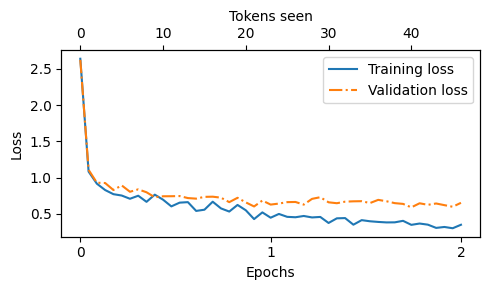

In [ ]:
import numpy as np

# train_losses has 18 elements based on the previous output
num_points = len(train_losses)
epochs_tensor = torch.linspace(0, num_epochs, num_points)

# Use a numerical placeholder for tokens_seen instead of the string
# This ensures the dimensions match (18,)
tokens_seen_placeholder = np.arange(num_points)

# Now calling the function with the raw lists, as it handles conversion internally
plot_losses(epochs_tensor, tokens_seen_placeholder, train_losses, val_losses)

## 7.7 Extracting and saving responses

In [ ]:
torch.manual_seed(123)

In [ ]:
BASE_CONFIG["context_length"]

1024

In [ ]:
for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
    )

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice

In [ ]:
from tqdm import tqdm
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    test_data[i]["model_response"] = response_text
with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)

100%|██████████| 110/110 [01:07<00:00,  1.62it/s]


In [ ]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a cheetah.'}


## 7.8 Evaluating the fine-tuned LLM

Idea: Utilizar como Juez uno de esos LLMs opensource a ver como le va frente a los otros. Ya creo que incluso tenemos cosas para evaluar.

## Apendix E: LoRa

#### Exercise 7.4 Parameter-efficient fine-tuning with LoRA

To instruction fine-tune an LLM more efficiently, modify the code in this chapter to use the **low-rank adaptation method (`LoRA`)** from **`appendix E`**. Compare the training run time and model performance before and after the modification.